# Task 3: Data Cleaning (Object Detection)
This notebook implements the AIN7101 Data Cleaning rubric, adapted for 4K Boreal Forest Fire images.
It applies a sequence-aware, 7-part cleaning pipeline.

In [6]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 3.6 MB/s  0:00:03m 3.7 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 4.0 MB/s  0:00:014.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imagehash]
Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
import glob
import hashlib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat
import imagehash

# Suppress DecompressionBombWarning for large 4K images
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

base_dir = "../../working-Boreal-Forest-Fire-Subset-A"
log_data = []  # To store the audit log [Step, Image, Issue Type, Detection Method, Treatment, Rationale]


## Part 1: Missing Values & Integrity (MCAR/MAR)

In [17]:
# Get all images and labels
image_files = sorted(glob.glob(os.path.join(base_dir, "*-Images", "*.jpg")))
label_files = sorted(glob.glob(os.path.join(base_dir, "*-Labels", "*.txt")))

image_stems = {os.path.splitext(os.path.basename(f))[0]: f for f in image_files}
label_stems = {os.path.splitext(os.path.basename(f))[0]: f for f in label_files}

valid_pairs = []

for stem in set(image_stems.keys()).union(set(label_stems.keys())):
    img_path = image_stems.get(stem)
    lbl_path = label_stems.get(stem)
    
    if not img_path:
        log_data.append(["Part 1", stem, "Missing Image", "File exist check", "Deleted label", "MCAR: Cannot train without image"])
        if lbl_path and os.path.exists(lbl_path): os.remove(lbl_path)
        continue
    if not lbl_path:
        log_data.append(["Part 1", stem, "Missing Label", "File exist check", "Deleted image", "MCAR: Cannot train without label"])
        if img_path and os.path.exists(img_path): os.remove(img_path)
        continue
        
    # Check 0-bytes
    if os.path.getsize(img_path) == 0:
        log_data.append(["Part 1", stem, "Corrupt Image", "0-byte check", "Deleted pair", "Image is empty"])
        os.remove(img_path)
        os.remove(lbl_path)
        continue
        
    # PIL Verify
    try:
        with Image.open(img_path) as img:
            img.verify()
        valid_pairs.append((img_path, lbl_path))
    except Exception as e:
        log_data.append(["Part 1", stem, "Corrupt Image", "PIL verify", "Deleted pair", f"Unreadable file: {str(e)}"])
        os.remove(img_path)
        os.remove(lbl_path)

print(f"Started with {len(image_files)} images and {len(label_files)} labels.")
print(f"Valid paired files after Part 1: {len(valid_pairs)}")


Started with 4954 images and 4954 labels.
Valid paired files after Part 1: 4954


## Part 2: Exact Duplicates

In [18]:
# MD5 Hash check
md5_hashes = {}
unique_pairs = []

for img_path, lbl_path in valid_pairs:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    with open(img_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        
    if file_hash in md5_hashes:
        log_data.append(["Part 2", stem, "Exact Duplicate", "MD5 Hash", "Deleted pair", f"Duplicate of {md5_hashes[file_hash]}"])
        os.remove(img_path)
        os.remove(lbl_path)
    else:
        md5_hashes[file_hash] = stem
        unique_pairs.append((img_path, lbl_path))
        
print(f"Unique files after MD5 check: {len(unique_pairs)}")


Unique files after MD5 check: 4954


## Part 3 & 4: Noisy Data, Outliers, and Consistency

In [19]:
# Read labels
import copy

final_pairs = []
areas = []
aspect_ratios = []
blur_scores = []

# Collect bounding-box statistics
for img_path, lbl_path in unique_pairs:
    with open(lbl_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) == 5:
            _, _, _, w, h = map(float, parts)

            areas.append(w * h)

            if h > 0:
                aspect_ratios.append(w / h)

# Calculate statistical thresholds
area_p01 = np.percentile(areas, 0.01) if areas else 0
area_p995 = np.percentile(areas, 99.5) if areas else 1

q1, q3 = (
    np.percentile(aspect_ratios, [25, 75])
    if aspect_ratios
    else (0, 1)
)

iqr = q3 - q1

ar_lower = q1 - 1.5 * iqr
ar_upper = q3 + 1.5 * iqr

print("Bounding Box Statistics")
print("-----------------------")
print(f"Number of boxes: {len(areas)}")
print(f"Area P0.01: {area_p01:.6f}")
print(f"Area P99.5: {area_p995:.6f}")
print(f"AR Q1: {q1:.4f}")
print(f"AR Q3: {q3:.4f}")
print(f"AR lower bound: {ar_lower:.4f}")
print(f"AR upper bound: {ar_upper:.4f}")

Bounding Box Statistics
-----------------------
Number of boxes: 4862
Area P0.01: 0.000288
Area P99.5: 0.896247
AR Q1: 0.7358
AR Q3: 1.0201
AR lower bound: 0.3093
AR upper bound: 1.4465


In [20]:
# Blur detection

for img_path, lbl_path in unique_pairs:
    stem = os.path.splitext(os.path.basename(img_path))[0]

    img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img_cv is not None:
        laplacian_var = cv2.Laplacian(
            img_cv,
            cv2.CV_64F
        ).var()

        blur_scores.append(laplacian_var)

        if laplacian_var < 50:
            log_data.append([
                "Part 3",
                stem,
                "Blurry Image",
                "Laplacian Var < 50",
                "Flagged",
                "Loss of 4K texture"
            ])

print("Blur detection completed.")
print(f"Images analyzed: {len(blur_scores)}")
print(f"Blurry images flagged: {sum(score < 50 for score in blur_scores)}")

Blur detection completed.
Images analyzed: 4954
Blurry images flagged: 431


In [21]:
# Bounding Box Validation

for img_path, lbl_path in unique_pairs:

    stem = os.path.splitext(
        os.path.basename(img_path)
    )[0]

    with open(lbl_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    file_modified = False

    for line in lines:

        parts = line.strip().split()

        # Invalid YOLO format
        if len(parts) != 5:
            log_data.append([
                "Part 4",
                stem,
                "Invalid Format",
                "Word count != 5",
                "Deleted annotation",
                "YOLO format corruption"
            ])

            file_modified = True
            continue

        cls_id, cx, cy, w, h = map(float, parts)

        # Class ID validation
        if cls_id != 0:
            cls_id = 0

            log_data.append([
                "Part 4",
                stem,
                "Wrong Class ID",
                "cls != 0",
                "Auto-corrected to 0",
                "Single class unification"
            ])

            file_modified = True

        # Degenerate boxes
        if w <= 0 or h <= 0:
            log_data.append([
                "Part 3",
                stem,
                "Degenerate Box",
                "w or h <= 0",
                "Deleted annotation",
                "Zero area box"
            ])

            file_modified = True
            continue

        # Out-of-bounds check
        coords = [cx, cy, w, h]

        out_of_bounds = False
        large_error = False

        for i, val in enumerate(coords):

            if val < 0 or val > 1:

                margin = max(
                    abs(0 - val),
                    abs(1 - val)
                )

                if margin >= 0.02:
                    large_error = True

                else:
                    coords[i] = max(
                        0.0,
                        min(1.0, val)
                    )

                    out_of_bounds = True

        # Large OOB
        if large_error:

            log_data.append([
                "Part 4",
                stem,
                "OOB Coords (Large)",
                "margin >= 0.02",
                "Deleted annotation",
                "Clipping shifts ground truth"
            ])

            file_modified = True
            continue

        # Small OOB
        elif out_of_bounds:

            log_data.append([
                "Part 4",
                stem,
                "OOB Coords (Small)",
                "margin < 0.02",
                "Clipped to [0,1]",
                "Negligible shift"
            ])

            file_modified = True

            cx, cy, w, h = coords

        # Area outlier
        area = w * h

        if (
            area < max(area_p01, 0.0001)
            or
            area > min(area_p995, 0.95)
        ):

            log_data.append([
                "Part 3",
                stem,
                "Area Outlier",
                "Percentile Bounds",
                "Flagged",
                f"Area: {area:.4f}"
            ])

        # Aspect ratio outlier
        ar = w / h

        if ar < ar_lower or ar > ar_upper:

            log_data.append([
                "Part 3",
                stem,
                "AR Outlier",
                "IQR Bounds",
                "Flagged",
                f"AR: {ar:.2f}"
            ])

        # Save valid annotation
        new_lines.append(
            f"{int(cls_id)} "
            f"{cx:.6f} "
            f"{cy:.6f} "
            f"{w:.6f} "
            f"{h:.6f}\n"
        )

    # Modify label only if necessary
    if file_modified:

        with open(lbl_path, 'w') as f:
            f.writelines(new_lines)

    final_pairs.append((img_path, lbl_path))

print("Bounding-box validation completed.")
print(f"Final pairs: {len(final_pairs)}")

Bounding-box validation completed.
Final pairs: 4954


In [22]:
from collections import Counter

print("Final pairs:", len(final_pairs))
print("Blur measurements:", len(blur_scores))

issue_counts = Counter(
    row[2] for row in log_data
)

print("\nCleaning Issues:")
for issue, count in issue_counts.items():
    print(f"{issue}: {count}")

Final pairs: 4954
Blur measurements: 4954

Cleaning Issues:
Blurry Image: 431
AR Outlier: 368
Area Outlier: 26


## Part 5: Sequential Consistency (Video-Aware)

In [24]:
from collections import defaultdict
import statistics
import imagehash
from PIL import Image


clips = defaultdict(list)

# Group frames by clip ID
for img_path, lbl_path in final_pairs:

    stem = os.path.splitext(os.path.basename(img_path))[0]

    # Example:
    # evoDJI_0009_frame71
    # -> evoDJI_0009

    clip_prefix = "_".join(stem.split("_")[:-1])

    clips[clip_prefix].append(
        (img_path, lbl_path, stem)
    )

# Sort frames chronologically
for prefix in clips:
    clips[prefix].sort(
        key=lambda x: int(x[2].split("_frame")[-1])
    )

print(f"Total clips: {len(clips)}")

Total clips: 31


In [25]:
# Part 5.1 — Box Count Shifts

box_count_shifts = 0

for prefix, frames in clips.items():

    # Number of bounding boxes in each frame
    box_counts = []

    for img_path, lbl_path, stem in frames:

        with open(lbl_path, "r") as f:
            lines = [
                line.strip()
                for line in f.readlines()
                if line.strip()
            ]

        box_counts.append(len(lines))

    # Find the most common box count in this clip
    if box_counts:

        try:
            mode_count = statistics.mode(box_counts)
        except statistics.StatisticsError:
            mode_count = box_counts[0]

        # Flag frames that deviate from the mode
        for idx, count in enumerate(box_counts):

            if count != mode_count:

                box_count_shifts += 1

                log_data.append([
                    "Part 5",
                    frames[idx][2],
                    "Box Count Shift",
                    "Mode deviation",
                    "Flagged",
                    "Smoke might have dissipated or annotation error"
                ])

print(f"Box Count Shifts: {box_count_shifts}")

Box Count Shifts: 193


In [26]:
# Part 5.2 — pHash Near-Duplicate Detection

near_duplicate_count = 0

for prefix, frames in clips.items():

    for i in range(1, len(frames)):

        prev_img, prev_lbl, prev_stem = frames[i - 1]
        curr_img, curr_lbl, curr_stem = frames[i]

        try:
            # Calculate perceptual hashes
            hash_prev = imagehash.phash(
                Image.open(prev_img)
            )

            hash_curr = imagehash.phash(
                Image.open(curr_img)
            )

            # Hamming distance
            distance = hash_prev - hash_curr

            # Near-duplicate threshold
            if distance < 5:

                near_duplicate_count += 1

                log_data.append([
                    "Part 5",
                    curr_stem,
                    "Near Duplicate",
                    "pHash < 5",
                    "Flagged",
                    "Temporal static scene"
                ])

        except Exception as e:
            print(
                f"pHash failed for {curr_stem}: {e}"
            )

print(f"Near Duplicates: {near_duplicate_count}")

Near Duplicates: 3389


In [27]:
# Part 5.2 — Analyze pHash Distances

phash_distances = []

for prefix, frames in clips.items():

    for i in range(1, len(frames)):

        prev_img, _, _ = frames[i - 1]
        curr_img, _, curr_stem = frames[i]

        try:
            hash_prev = imagehash.phash(
                Image.open(prev_img)
            )

            hash_curr = imagehash.phash(
                Image.open(curr_img)
            )

            distance = hash_prev - hash_curr
            phash_distances.append(distance)

        except Exception as e:
            print(f"pHash failed for {curr_stem}: {e}")

print(f"Total consecutive comparisons: {len(phash_distances)}")
print(f"Minimum distance: {min(phash_distances)}")
print(f"Maximum distance: {max(phash_distances)}")
print(f"Mean distance: {np.mean(phash_distances):.2f}")
print(f"Median distance: {np.median(phash_distances):.2f}")

print("\nCounts by threshold:")

for threshold in [1, 2, 3, 4, 5, 6, 7, 8, 10]:

    count = sum(
        d < threshold
        for d in phash_distances
    )

    print(
        f"distance < {threshold}: {count}"
    )

Total consecutive comparisons: 4923
Minimum distance: 0
Maximum distance: 42
Mean distance: 5.35
Median distance: 4.00

Counts by threshold:
distance < 1: 919
distance < 2: 919
distance < 3: 2423
distance < 4: 2423
distance < 5: 3389
distance < 6: 3389
distance < 7: 3856
distance < 8: 3856
distance < 10: 4122


## Part 6: Data Drift Awareness
Based on Task 2, we identified:
1. **Temporal Drift:** Mean box displacement of 0.041 between frames.
2. **Illumination Drift:** Brightness bias towards daytime (mean 110/255).
3. **Spatial Drift:** Horizon bias (mean Y-center = 0.395).

Static global imputation (which we rejected) would fail to account for these dynamic shifts across video sequences.

## Part 7: Logging and Visualization

Total flags/modifications logged: 4407


,Step,Image,Issue Type,Detection Method,Treatment,Rationale
0,Part 3,evoDJI_0007_frame118,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
1,Part 3,evoDJI_0009_frame168,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
2,Part 3,evoDJI_0009_frame257,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
3,Part 3,evoDJI_0001_frame3,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
4,Part 3,evoDJI_0009_frame148,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
5,Part 3,evoDJI_0007_frame326,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
6,Part 3,heinola_DJI_0036_frame117,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
7,Part 3,evoDJI_0009_frame126,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
8,Part 3,heinola_DJI_0048_frame101,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture
9,Part 3,evoDJI_0007_frame146,Blurry Image,Laplacian Var < 50,Flagged,Loss of 4K texture


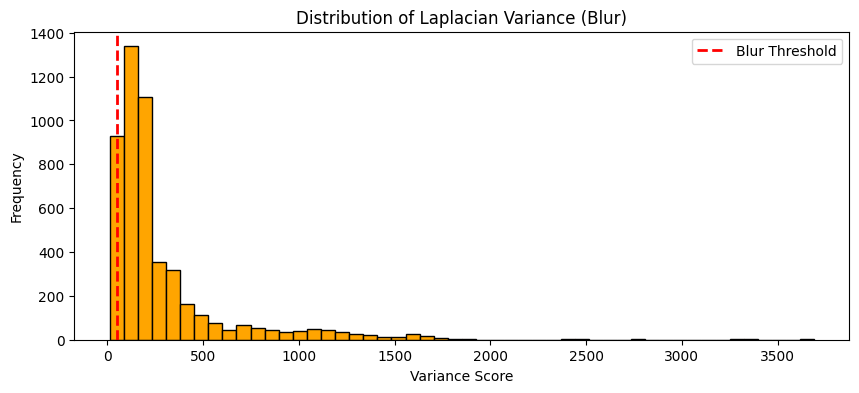

In [28]:
# DataFrame Export
df_log = pd.DataFrame(log_data, columns=["Step", "Image", "Issue Type", "Detection Method", "Treatment", "Rationale"])
df_log.to_csv("cleaning_log.csv", index=False)

print(f"Total flags/modifications logged: {len(df_log)}")
display(df_log.head(10))

# Plotting Blur
plt.figure(figsize=(10,4))
plt.hist(blur_scores, bins=50, color='orange', edgecolor='black')
plt.axvline(50, color='red', linestyle='dashed', linewidth=2, label='Blur Threshold')
plt.title("Distribution of Laplacian Variance (Blur)")
plt.xlabel("Variance Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("blur_dist.png")
plt.show()
